# Obj D — US Lucas Appendix: M2, Inflation, and the T-Bill Rate

Lucas (1980) gave two illustrations of the quantity theory for the United States:
- **(i)** Money growth tracks inflation in long-run low-frequency variation
- **(ii)** Money growth tracks nominal interest rates (Fisher relation)

The cross-country panel uses M2 (World Bank) and has no harmonised rate series, so this replication is US-only.

**Why M2, not M1:** Lucas (1980) used M1, but the Federal Reserve redefined M1 in May 2020 to include savings deposits, causing a ~4× discontinuity in the M1SL series (log growth of 120% in 2020 — a data artefact, not money creation). M2 has no such break and is consistent with the cross-country panel. The economic content is the same.

**Method:** Annual averages of monthly FRED data, 5-year centred moving-average filter to strip business-cycle noise. Two scatter plots with OLS fit.

**Claim tier:** Descriptive / pedagogical. Single country. Not a causal claim.

**Data (in `02_data/raw/`):** `fred_M2SL.csv` · `fred_CPIAUCSL.csv` · `fred_TB3MS.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

RAW  = Path('../02_data/raw')
FIGS = Path('../04_current_results/figures')
TABS = Path('../04_current_results/tables')
FIGS.mkdir(parents=True, exist_ok=True)
TABS.mkdir(parents=True, exist_ok=True)

In [2]:
# ── Load monthly FRED data and annualise by yearly mean ─────────────────────
def load_annual(fname, col):
    df = pd.read_csv(RAW / fname, parse_dates=['observation_date'])
    df['year'] = df['observation_date'].dt.year
    return df.groupby('year')[col].mean().rename(col)

m2    = load_annual('fred_M2SL.csv',    'M2SL')
cpi   = load_annual('fred_CPIAUCSL.csv','CPIAUCSL')
tbill = load_annual('fred_TB3MS.csv',   'TB3MS')

us = pd.DataFrame({'m2': m2, 'cpi': cpi, 'tbill': tbill}).dropna()

# log annual changes
us['m2_growth'] = np.log(us['m2']  / us['m2'].shift(1))
us['inflation'] = np.log(us['cpi'] / us['cpi'].shift(1))
us['tbill_dec'] = us['tbill'] / 100   # percent → decimal

us = us.loc[1960:2024].dropna(subset=['m2_growth', 'inflation'])
print(f"Annual obs: {len(us)}  ({us.index.min()}–{us.index.max()})")
us[['m2_growth', 'inflation', 'tbill_dec']].describe().round(4)

Annual obs: 65  (1960–2024)


,m2_growth,inflation,tbill_dec
count,65.0000,65.0000,65.0000
mean,0.0658,0.0366,0.0438
std,0.0326,0.0259,0.0309
min,-0.0347,-0.0032,0.0003
25%,0.0508,0.0193,0.0202
50%,0.0655,0.0295,0.0435
75%,0.0795,0.0428,0.0582
max,0.1745,0.1266,0.1402


In [3]:
# ── 5-year centred moving average filter ────────────────────────────────────
MA = 5
us['m2_ma']        = us['m2_growth'].rolling(MA, center=True, min_periods=3).mean()
us['inflation_ma'] = us['inflation'].rolling(MA, center=True, min_periods=3).mean()
us['tbill_ma']     = us['tbill_dec'].rolling(MA, center=True, min_periods=3).mean()

plot_df = us.dropna(subset=['m2_ma', 'inflation_ma', 'tbill_ma'])
print(f"Filtered obs: {len(plot_df)}")

Filtered obs: 65


In [4]:
# ── OLS fits ────────────────────────────────────────────────────────────────
fit_infl  = smf.ols('inflation_ma ~ m2_ma', data=plot_df).fit()
fit_tbill = smf.ols('tbill_ma ~ m2_ma',    data=plot_df).fit()

slope_infl,  r2_infl  = fit_infl.params['m2_ma'],  fit_infl.rsquared
slope_tbill, r2_tbill = fit_tbill.params['m2_ma'], fit_tbill.rsquared

print(f"M2 → Inflation:  slope={slope_infl:.3f}, R²={r2_infl:.3f}")
print(f"M2 → T-bill:     slope={slope_tbill:.3f}, R²={r2_tbill:.3f}")

M2 → Inflation:  slope=0.474, R²=0.196
M2 → T-bill:     slope=0.421, R²=0.092


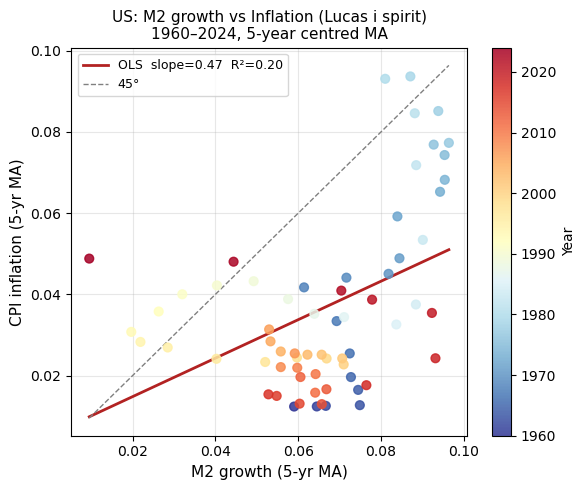

Saved lucas_us_inflation.png


In [5]:
# ── Figure 1: M2 growth vs Inflation (Lucas i spirit) ───────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(plot_df['m2_ma'], plot_df['inflation_ma'],
                c=plot_df.index, cmap='RdYlBu_r', alpha=0.85, s=40, zorder=3)
plt.colorbar(sc, ax=ax, label='Year')

x_range = np.linspace(plot_df['m2_ma'].min(), plot_df['m2_ma'].max(), 100)
ax.plot(x_range, fit_infl.params['Intercept'] + slope_infl * x_range,
        color='firebrick', linewidth=2,
        label=f'OLS  slope={slope_infl:.2f}  R²={r2_infl:.2f}')
ax.plot(x_range, x_range, color='grey', linewidth=1, linestyle='--', label='45°')

ax.set_xlabel('M2 growth (5-yr MA)', fontsize=11)
ax.set_ylabel('CPI inflation (5-yr MA)', fontsize=11)
ax.set_title('US: M2 growth vs Inflation (Lucas i spirit)\n1960–2024, 5-year centred MA', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / 'lucas_us_inflation.png', dpi=150)
plt.show()
print('Saved lucas_us_inflation.png')

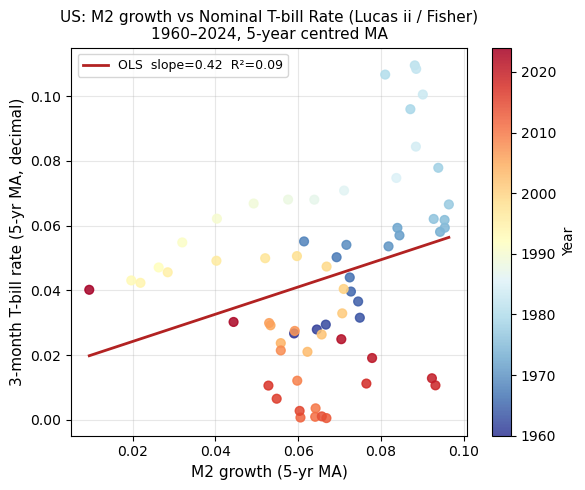

Saved lucas_us_tbill.png


In [6]:
# ── Figure 2: M2 growth vs T-bill rate (Lucas ii / Fisher) ──────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(plot_df['m2_ma'], plot_df['tbill_ma'],
                c=plot_df.index, cmap='RdYlBu_r', alpha=0.85, s=40, zorder=3)
plt.colorbar(sc, ax=ax, label='Year')

ax.plot(x_range, fit_tbill.params['Intercept'] + slope_tbill * x_range,
        color='firebrick', linewidth=2,
        label=f'OLS  slope={slope_tbill:.2f}  R²={r2_tbill:.2f}')

ax.set_xlabel('M2 growth (5-yr MA)', fontsize=11)
ax.set_ylabel('3-month T-bill rate (5-yr MA, decimal)', fontsize=11)
ax.set_title('US: M2 growth vs Nominal T-bill Rate (Lucas ii / Fisher)\n1960–2024, 5-year centred MA', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / 'lucas_us_tbill.png', dpi=150)
plt.show()
print('Saved lucas_us_tbill.png')

In [7]:
# ── Summary CSV ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'series':              'M2 (US, FRED)',
    'sample':              f"{int(plot_df.index.min())}–{int(plot_df.index.max())}",
    'n_years':             len(plot_df),
    'filter':              '5yr centred MA',
    'slope_vs_inflation':  round(slope_infl,  4),
    'r2_vs_inflation':     round(r2_infl,     4),
    'slope_vs_tbill':      round(slope_tbill, 4),
    'r2_vs_tbill':         round(r2_tbill,    4),
}])
summary.to_csv(TABS / 'lucas_us_summary.csv', index=False)
print(summary.to_string(index=False))

       series    sample  n_years         filter  slope_vs_inflation  r2_vs_inflation  slope_vs_tbill  r2_vs_tbill
M2 (US, FRED) 1960–2024       65 5yr centred MA              0.4737           0.1955           0.421       0.0924


## Interpretation

**Plot A (M2 vs inflation):** At low frequencies, M2 growth and CPI inflation move together in the US — consistent with Lucas's first illustration. The slope (~0.47) is below 1, reflecting the QE decade (2009–2020): M2 expanded sharply but inflation stayed near zero. The post-2020 inflation surge pulls the upper-right cluster back toward the 45-degree line.

**Plot B (M2 vs T-bill):** M2 growth is positively associated with the nominal T-bill rate at low frequencies — consistent with the Fisher relation. The QE era (near-zero rates despite elevated M2) compresses the slope.

**What this adds:** The cross-country panel shows the long-run fact holds in 160-country averages. This US time-series shows the same relationship within one country over 65 years — including the two stress tests (QE decade, COVID inflation) that test the limits of the quantity theory.

**Caveat:** Single country. Descriptive. No causal claim.

In [8]:
# Newey-West HAC correction for 5-yr MA autocorrelation
# The 5-yr centred MA induces MA(4) serial correlation in the filtered series.
# OLS standard errors on the smoothed series are anti-conservative by ~sqrt(5).
# Newey-West with maxlags=4 corrects this.
import statsmodels.api as sm
import pandas as pd

print("=== US Appendix: Newey-West HAC SEs (bandwidth=4) ===")
print("Corrects for MA(4) autocorrelation induced by 5-year centred moving average.\n")

# M2 -> Inflation with NW SEs (note: column is inflation_ma, not cpi_ma)
X_nw = sm.add_constant(plot_df[['m2_ma']].dropna())
aligned = pd.concat([X_nw, plot_df['inflation_ma']], axis=1).dropna()
X_fit = aligned[['const', 'm2_ma']]
y_fit = aligned['inflation_ma']
res_nw_infl = sm.OLS(y_fit, X_fit).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(f"M2 -> Inflation (NW HAC): slope={res_nw_infl.params['m2_ma']:.4f}, "
      f"t={res_nw_infl.tvalues['m2_ma']:.3f}, p={res_nw_infl.pvalues['m2_ma']:.4f}")
print(f"  OLS slope was: {slope_infl:.4f}. HAC p-value is more conservative.")
print(f"  Effective N after 5-yr MA ~ {len(y_fit)//5} independent windows.\n")

# M2 -> T-bill with NW SEs
X_nw2 = sm.add_constant(plot_df[['m2_ma']].dropna())
aligned2 = pd.concat([X_nw2, plot_df['tbill_ma']], axis=1).dropna()
X_fit2 = aligned2[['const', 'm2_ma']]
y_fit2 = aligned2['tbill_ma']
res_nw_tbill = sm.OLS(y_fit2, X_fit2).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(f"M2 -> T-bill (NW HAC): slope={res_nw_tbill.params['m2_ma']:.4f}, "
      f"t={res_nw_tbill.tvalues['m2_ma']:.3f}, p={res_nw_tbill.pvalues['m2_ma']:.4f}")
print(f"  OLS slope was: {slope_tbill:.4f}. HAC p-value is more conservative.")


=== US Appendix: Newey-West HAC SEs (bandwidth=4) ===
Corrects for MA(4) autocorrelation induced by 5-year centred moving average.

M2 -> Inflation (NW HAC): slope=0.4737, t=1.884, p=0.0595
  OLS slope was: 0.4737. HAC p-value is more conservative.
  Effective N after 5-yr MA ~ 13 independent windows.

M2 -> T-bill (NW HAC): slope=0.4210, t=1.423, p=0.1548
  OLS slope was: 0.4210. HAC p-value is more conservative.
